In [1]:
import sys
sys.path.append('../python-pipeline/')
from modules import *
from wavelets import *
from utils import prony

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, integrate, stats
import seaborn as sn

%matplotlib inline
plt.rcParams['figure.dpi'] = 300

In [3]:
sampleFreq = 64
numFreq = 5
# frequencies = torch.logspace(math.log10(1/3), math.log10(12), numFreq, base=10)
# frequencies = torch.tensor([0.4770, 0.9767, 2.0000, 4.0953, 8.3859])
frequencies = torch.tensor([0.5, 1.0, 2.0, 4.0, 8.0])

waveletFunc = accelerationWavelet

widths = (sampleFreq / frequencies).to(torch.int) # in samples
maxWidth = torch.max(widths).item() - 1 # in samples
print(maxWidth)

filterBank = torch.stack([waveletFunc(maxWidth, w) for w in widths])

127


Text(0.5, 0, 'Time [s]')

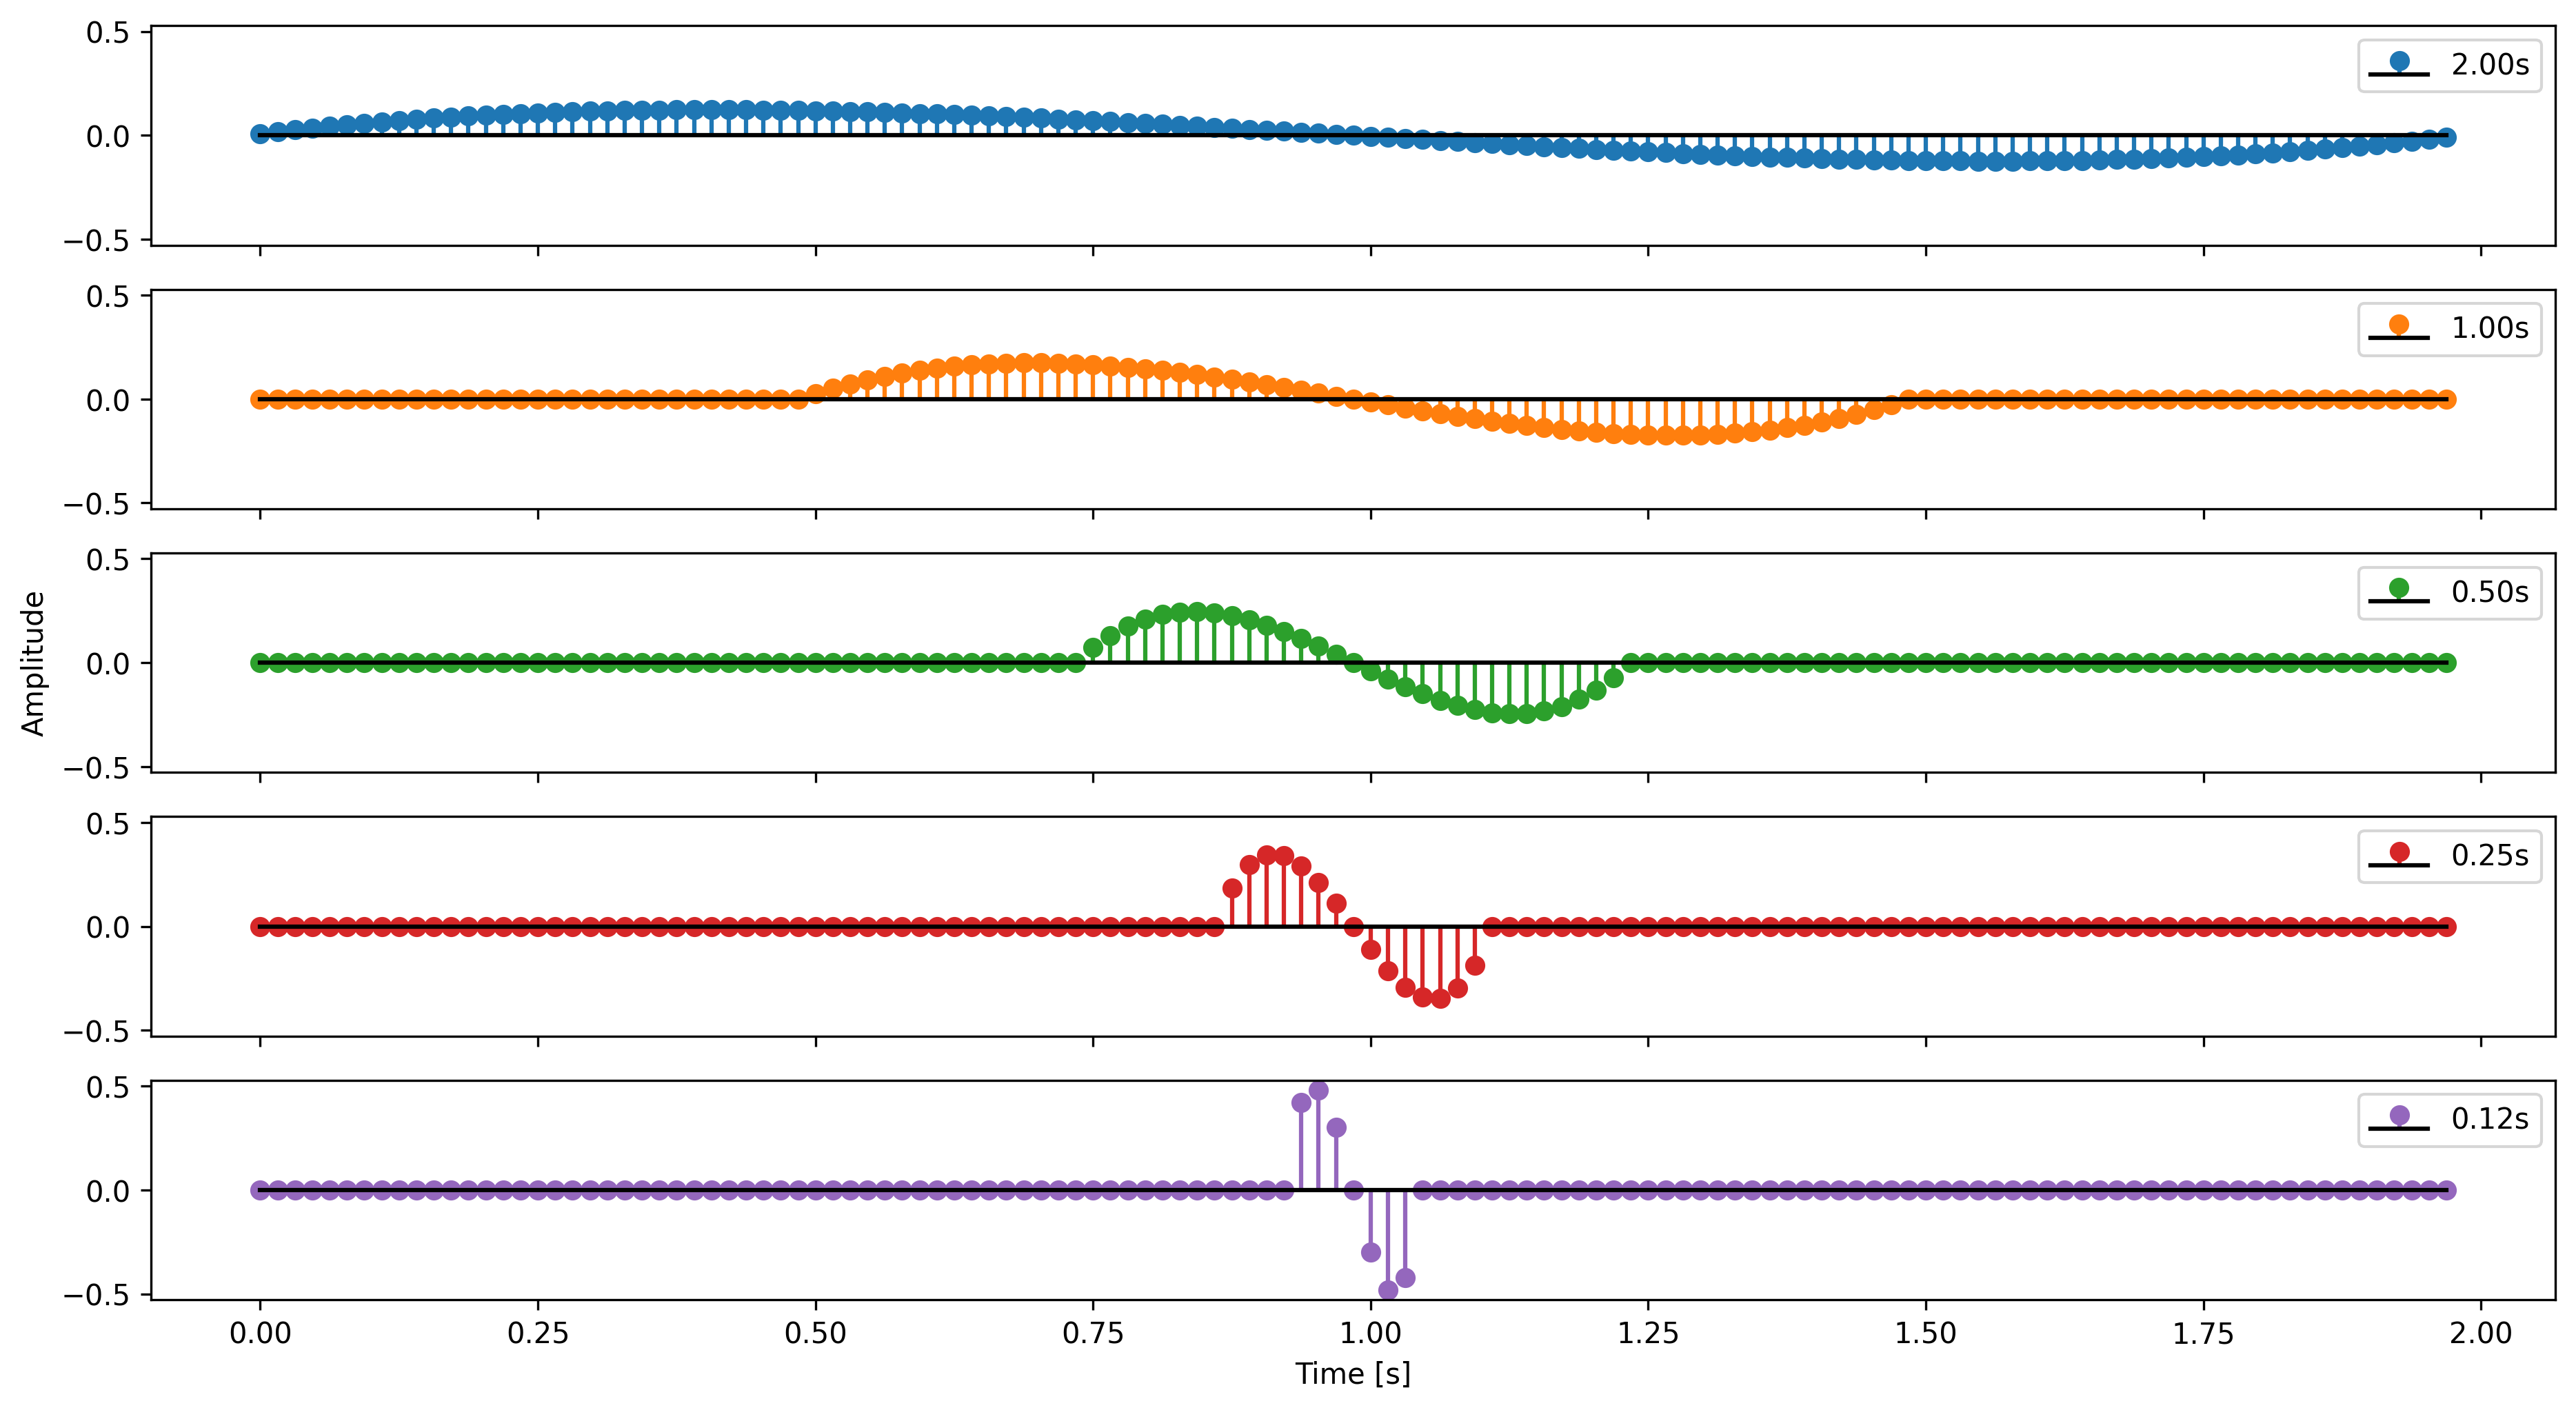

In [4]:
fig, ax = plt.subplots(5, 1, figsize=(15,8), sharex=True, sharey=True)

for fi, f in enumerate(filterBank.numpy()):
    ax[fi].stem(np.arange(maxWidth) / sampleFreq, f, basefmt='k', linefmt=f'C{fi}', label=f'{1/frequencies[fi]:.2f}s')
    ax[fi].legend()

ax[2].set_ylabel('Amplitude')
ax[4].set_xlabel('Time [s]')

In [5]:
len([0]*(maxWidth-1)+[1]), len(list(filterBank[0].numpy()))

(127, 127)

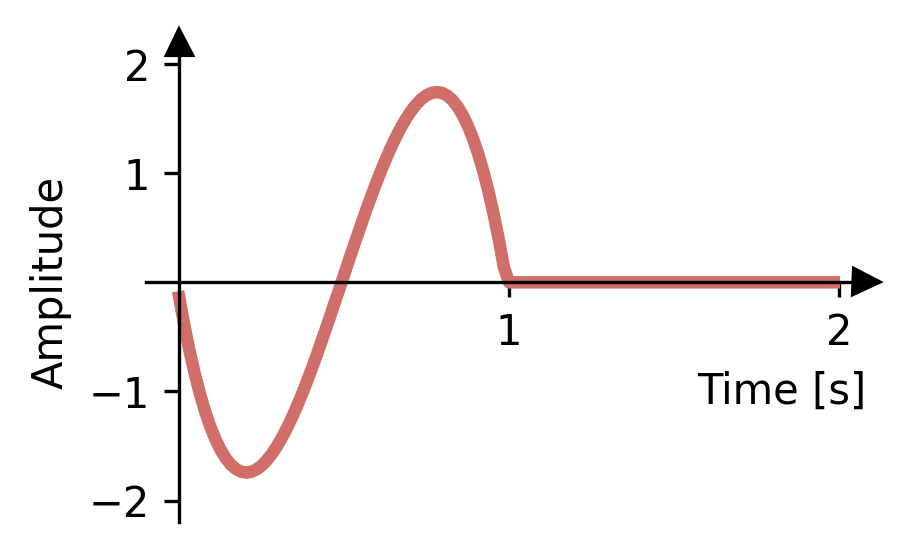

In [12]:
filterBankShort = [waveletFunc(w, w) for w in widths]

fig, ax = plt.subplots(1, 1, figsize=(3,2), sharex=True, sharey=True)
fig.subplots_adjust(bottom=0.1, top=0.9, left=0.15, right=0.95)

ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

b, a = list(-filterBankShort[1]), [1] + [0] * (widths[1] - 1)
dlti = signal.dlti(b, a, dt=1/sampleFreq)
t_, y_ = signal.dimpulse(dlti, t=np.arange(2*widths[1])/sampleFreq)
ax.plot(t_, 10*np.squeeze(y_), color=f'#d06f6aff', lw=3)

ax.set_ylabel('Amplitude')
ax.set_xlabel('Time [s]', loc='right')
ax.set_xticks([1,2])
ax.set_yticks([-2,-1,1,2])
ax.set_ylim(-2.2,2.2)
fig.savefig('./../results/fir_filter.pdf', dpi=150)

/home/igavier_umass_edu/.conda/envs/P2P-classifier/lib/python3.11/site-packages/scipy/signal/_ltisys.py:3492: RuntimeWarning: divide by zero encountered in log10
  mag = 20.0 * np.log10(abs(y))
/home/igavier_umass_edu/.conda/envs/P2P-classifier/lib/python3.11/site-packages/scipy/signal/_filter_design.py:701: RuntimeWarning: divide by zero encountered in divide
  gd = np.real(num / den) - a.size + 1
/home/igavier_umass_edu/.conda/envs/P2P-classifier/lib/python3.11/site-packages/scipy/signal/_filter_design.py:701: RuntimeWarning: invalid value encountered in divide
  gd = np.real(num / den) - a.size + 1
/tmp/ipykernel_2137951/2194317339.py:6: UserWarning: The group delay is singular at frequencies [0.000], setting to 0
  w, gd = signal.group_delay((list(filterBank[i].numpy()), [1]+[0]*(maxWidth-1)), w=w, fs=2*np.pi*sampleFreq)
/home/igavier_umass_edu/.conda/envs/P2P-classifier/lib/python3.11/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients

Text(0.5, 0, 'Frequency [Hz]')

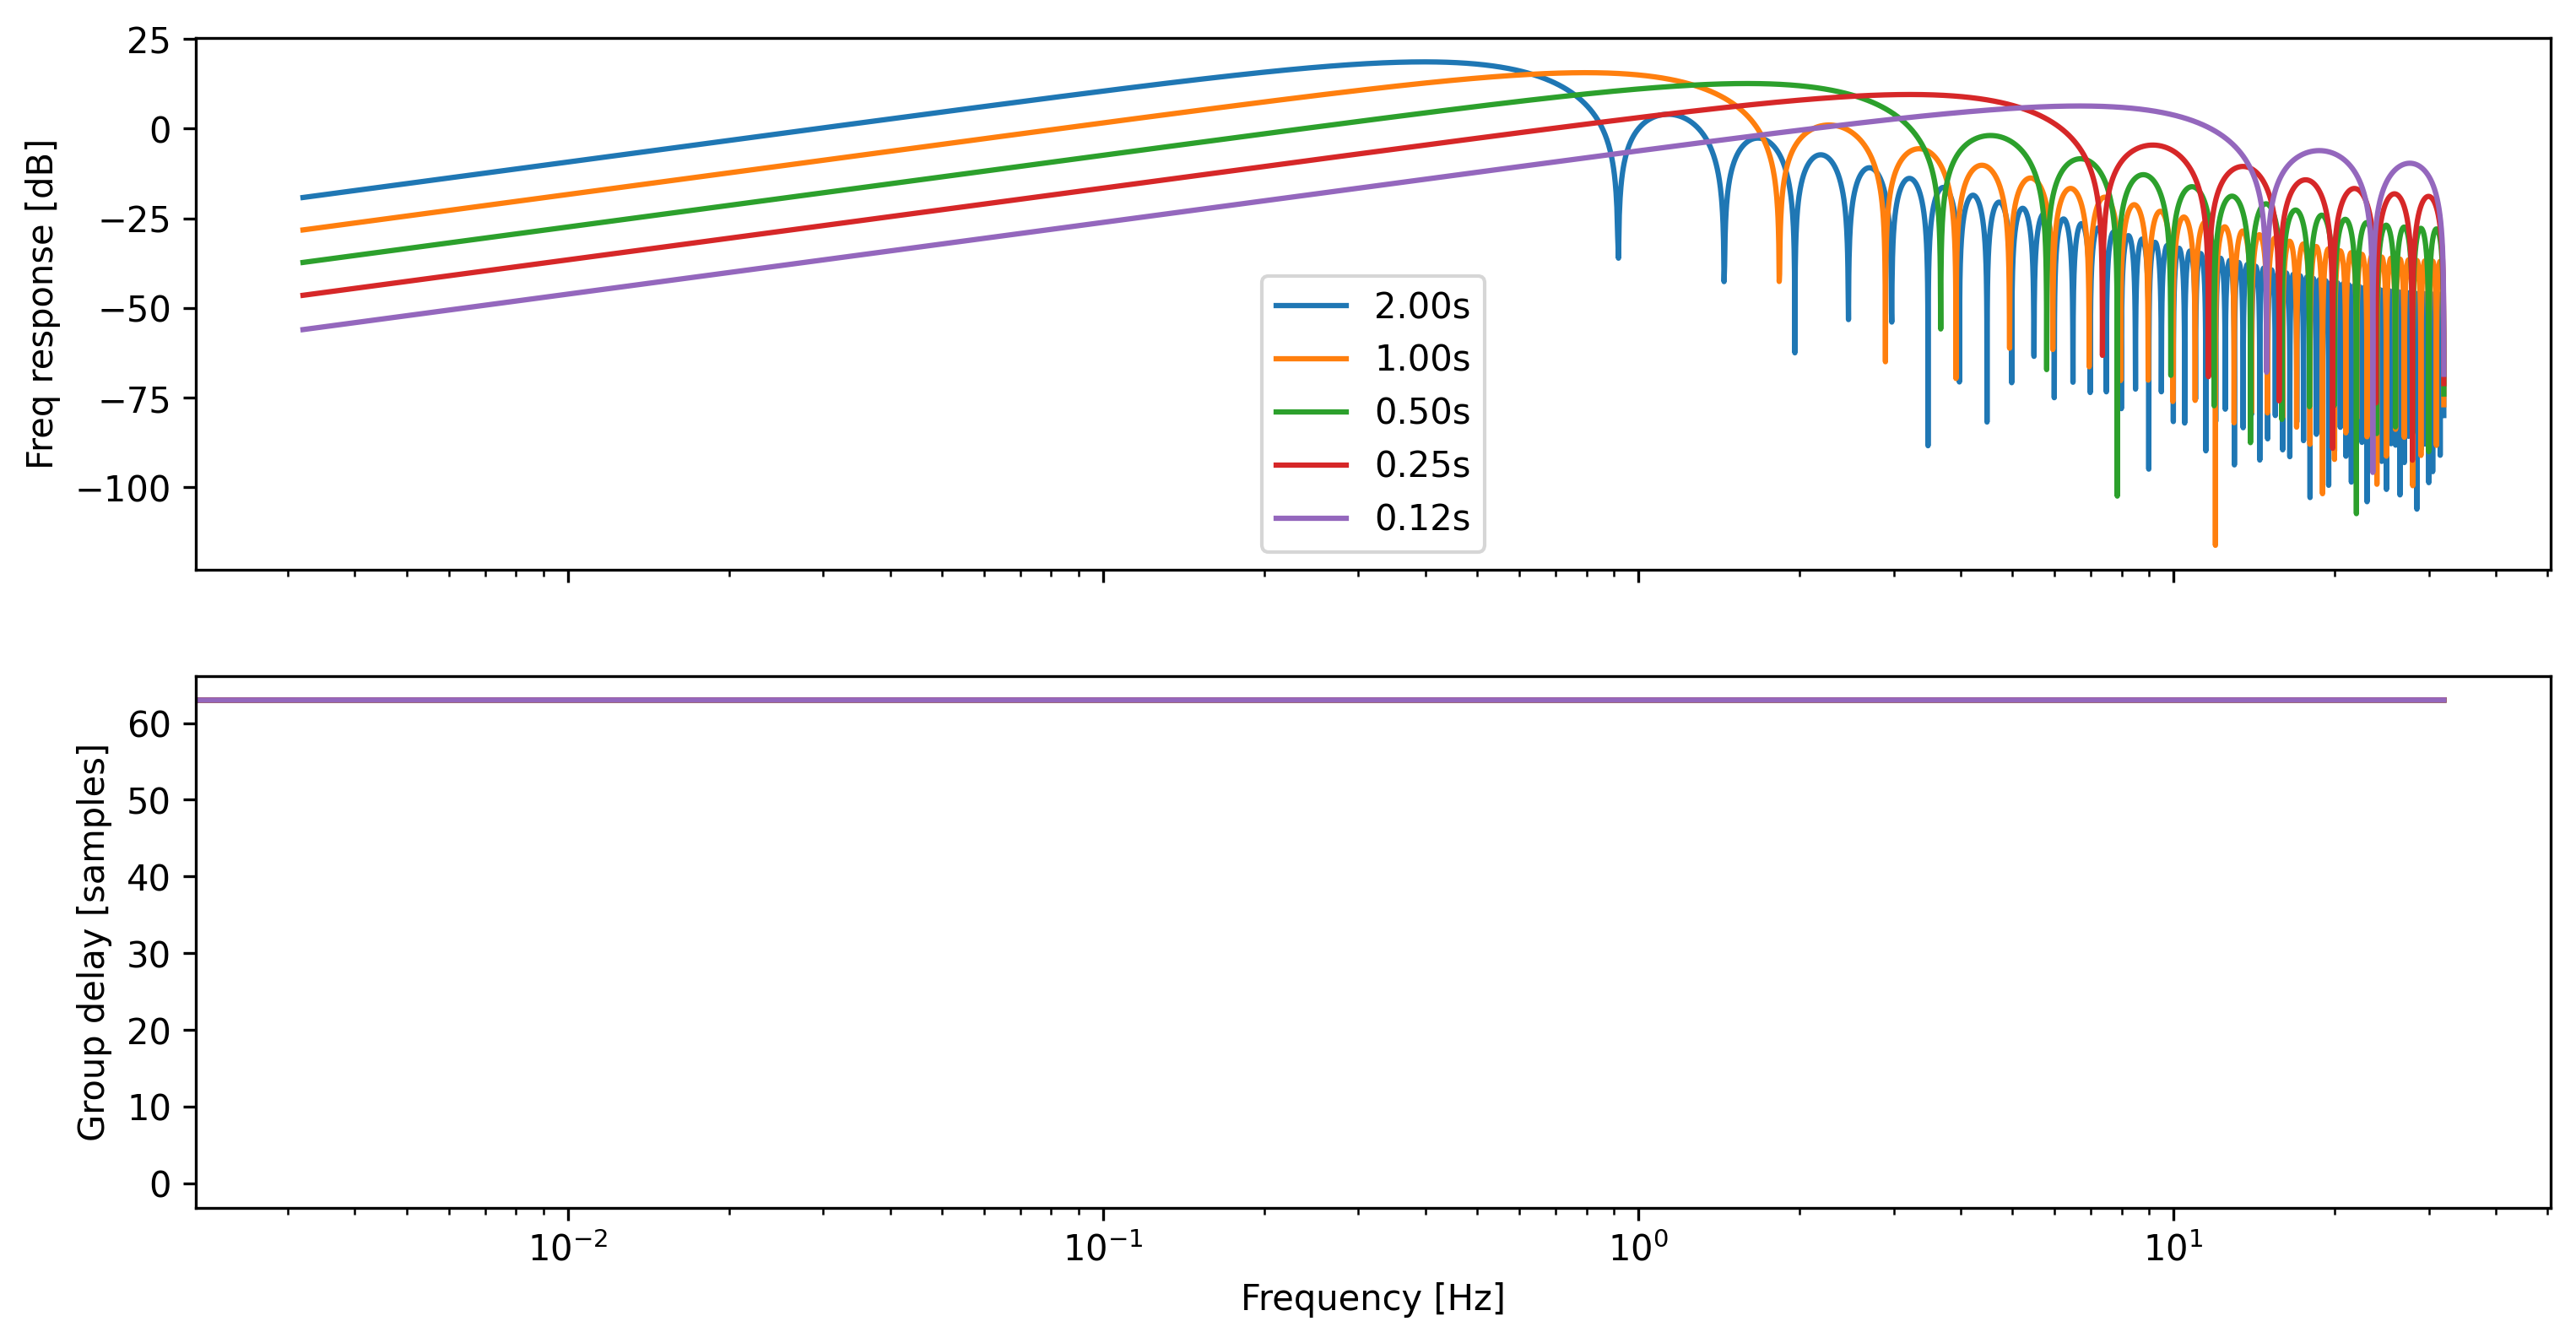

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(12,6), sharex=True)

for i in range(5):
    dlti = signal.dlti(list(filterBank[i].numpy()), [1]+[0]*(maxWidth-1), dt=1/sampleFreq)
    w, mag, phase = signal.dbode(dlti, n=10_000)
    w, gd = signal.group_delay((list(filterBank[i].numpy()), [1]+[0]*(maxWidth-1)), w=w, fs=2*np.pi*sampleFreq)
    ax[0].semilogx(w/(2*np.pi), mag, label=f'{1/frequencies[i]:.2f}s')
    # ax[1].semilogx(w/(2*np.pi), phase)
    ax[1].semilogx(w/(2*np.pi), gd)
ax[0].legend()
ax[0].set_ylabel('Freq response [dB]')
ax[1].set_ylabel('Group delay [samples]')
ax[1].set_xlabel('Frequency [Hz]')

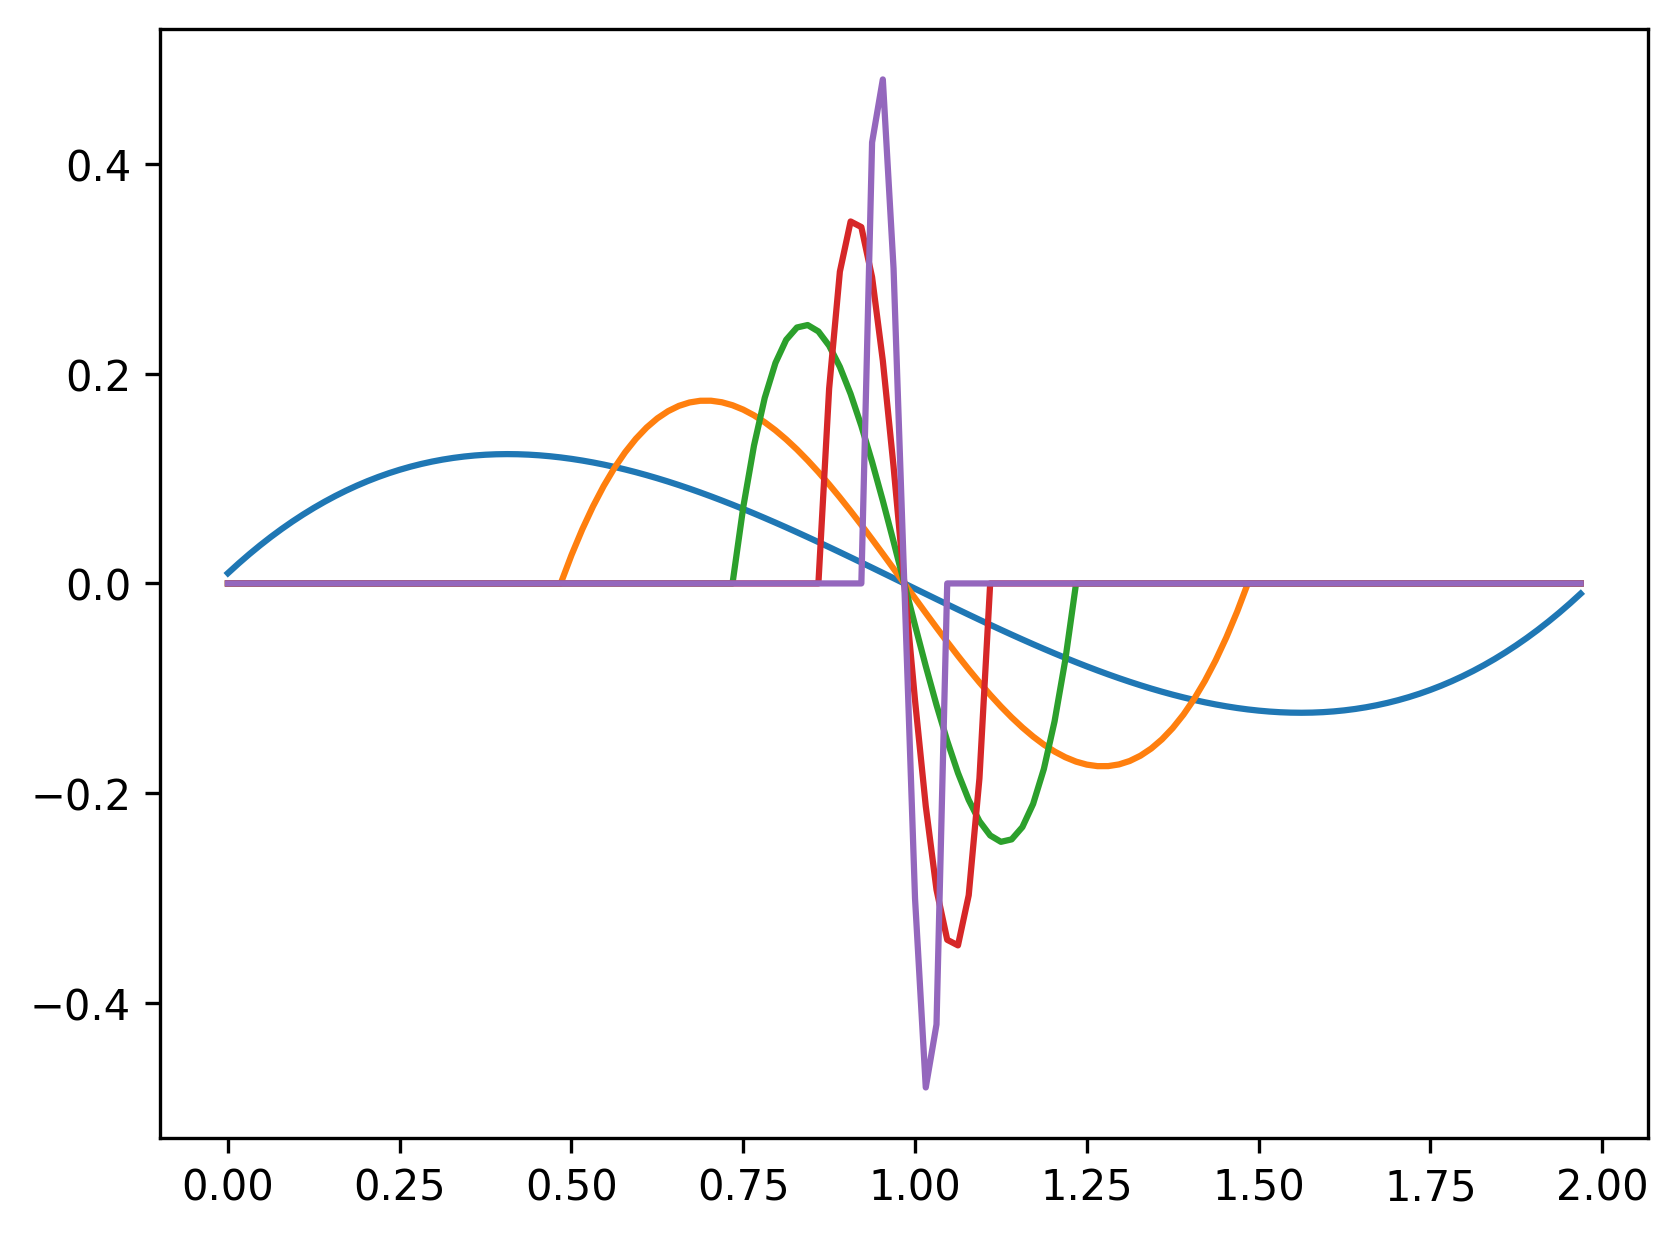

In [9]:
for i in range(5):
    dlti = signal.dlti(list(filterBank[i].numpy()), [1]+[0]*(maxWidth-1), dt=1/sampleFreq)
    t, y = signal.dimpulse(dlti, t=np.arange(maxWidth)/sampleFreq)
    plt.plot(t, np.squeeze(y))

tensor([ 32768., -64557.,  31871.]) tensor([20., 19., -1.])
tensor([ 32768., -63532.,  31084.]) tensor([57., 52., -3.])
tensor([ 32768., -61314.,  29759.]) tensor([156., 132., -15.])
tensor([ 32768., -56071.,  27683.]) tensor([421., 304., -52.])
tensor([ 32768., -42686.,  24403.]) tensor([1077.,  597., -111.])


Text(0.5, 0, 'Time [s]')

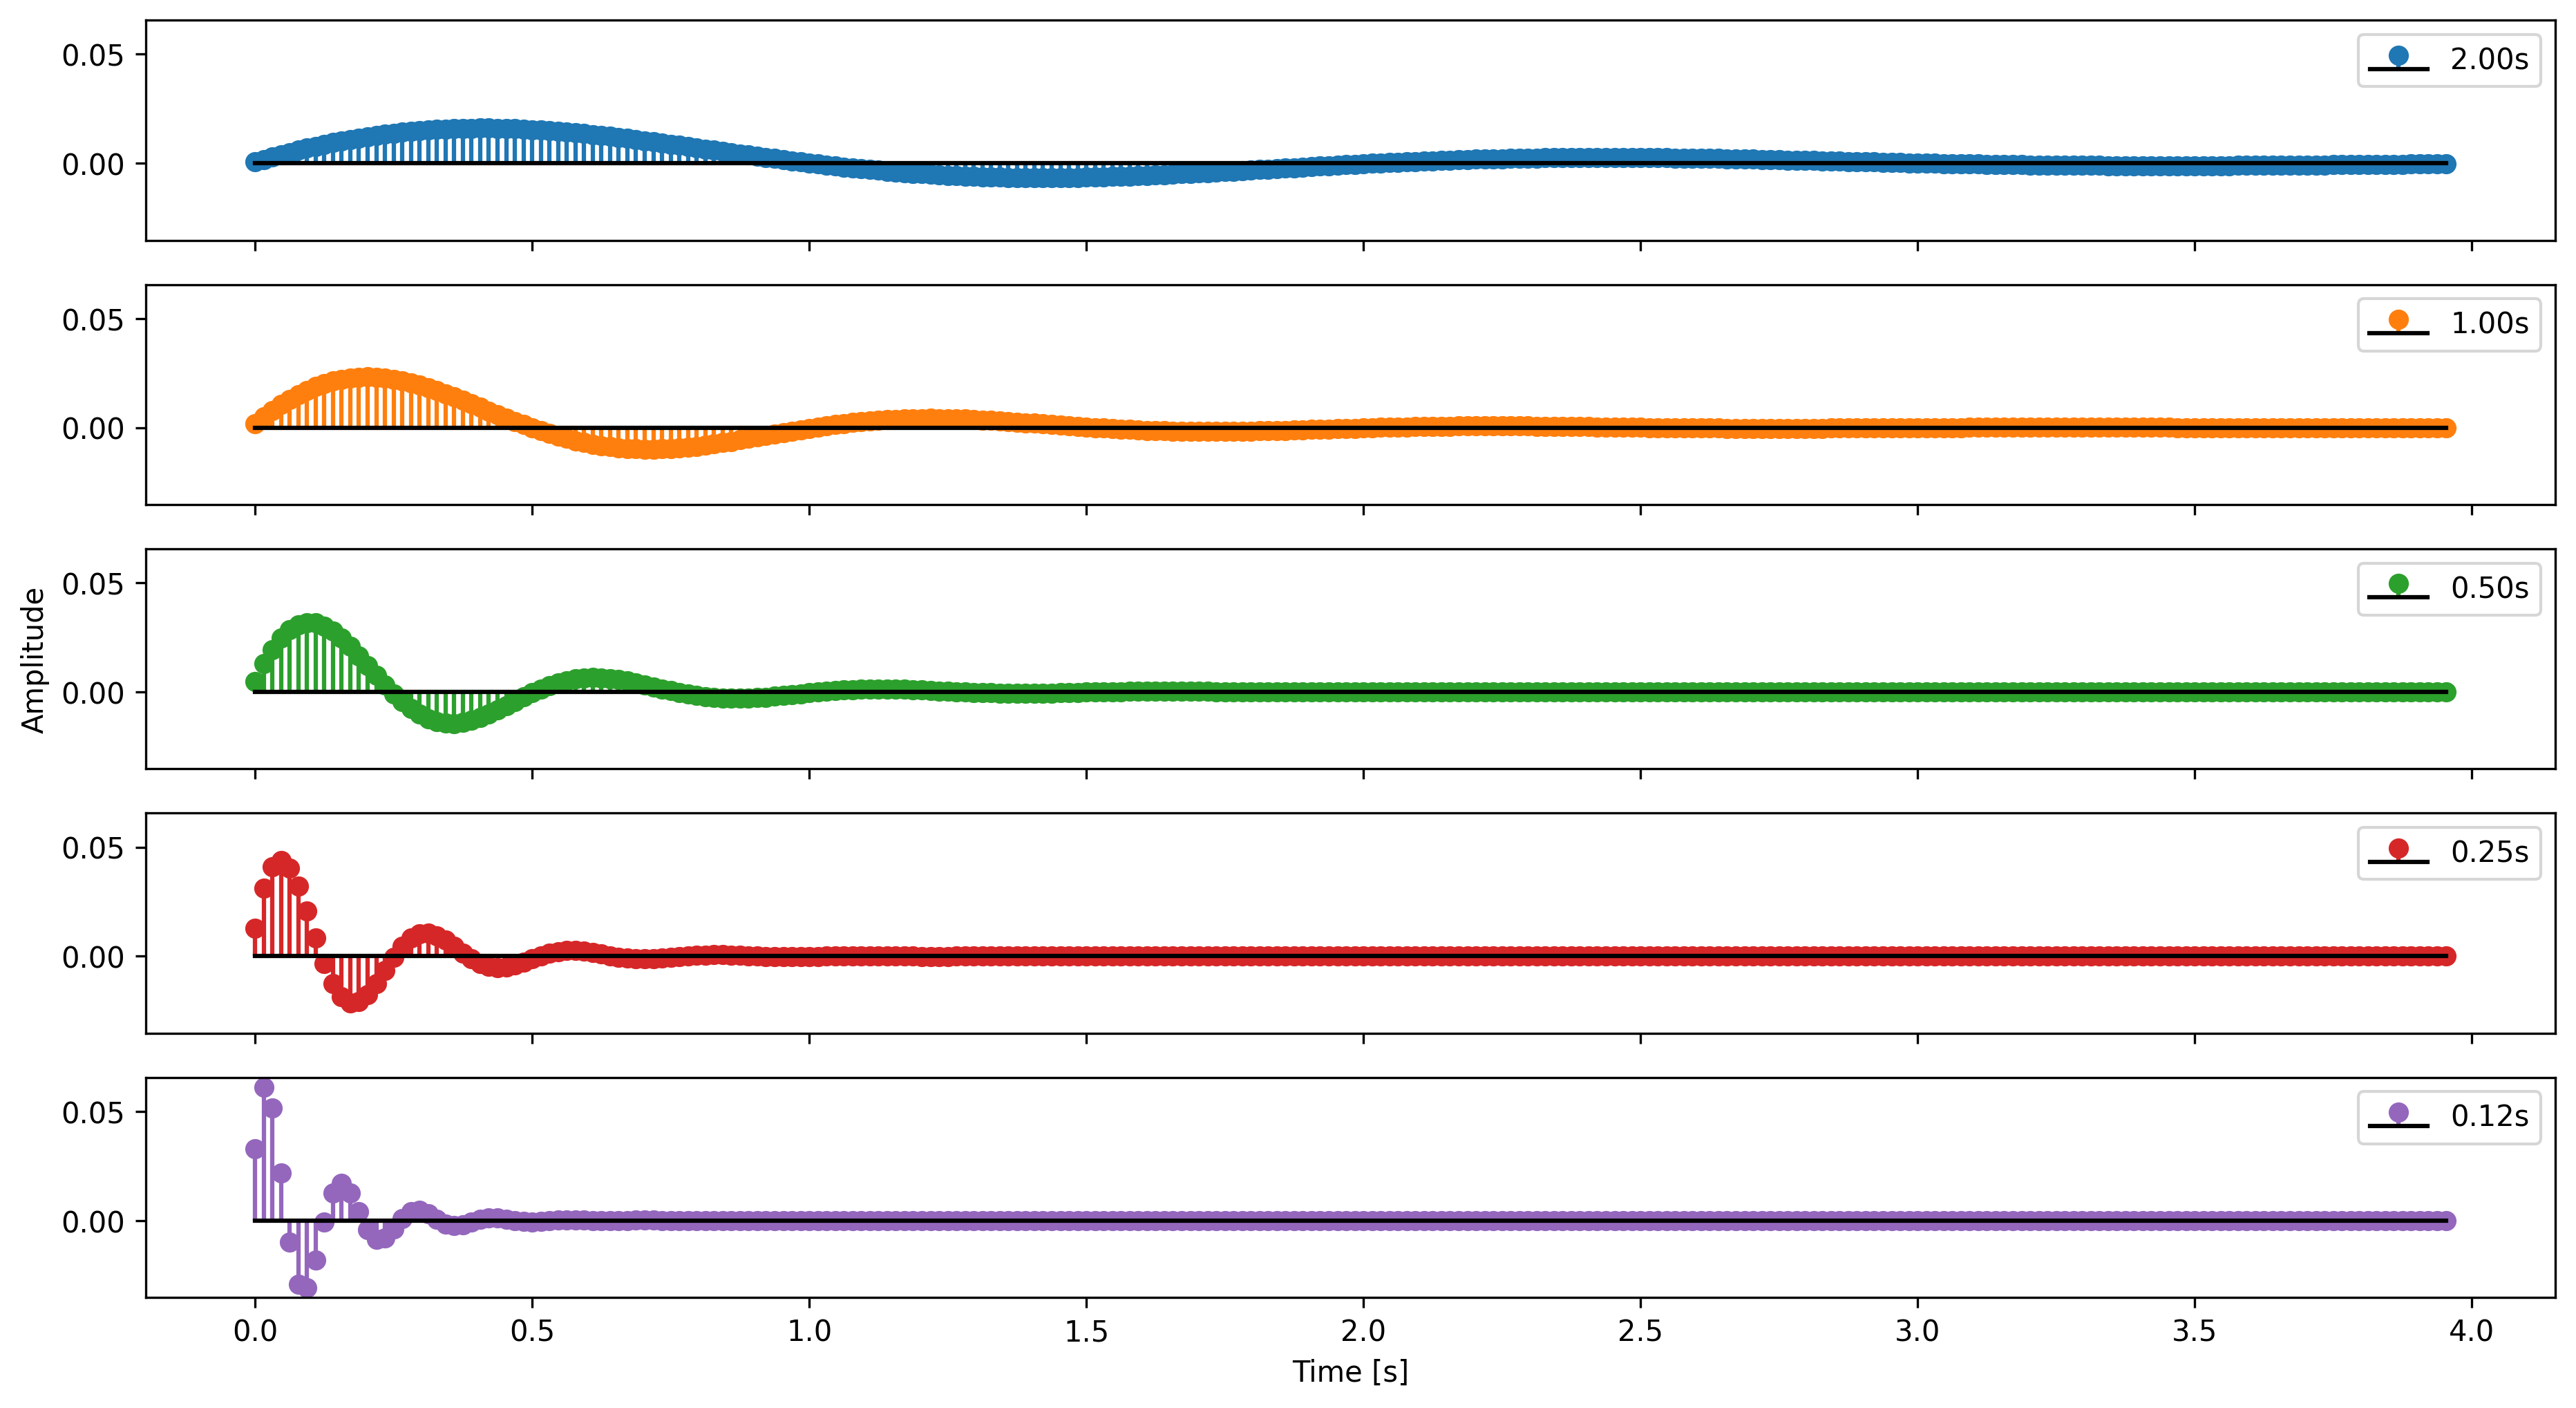

In [10]:
filterBankShort = [waveletFunc(w, w) for w in widths]

fig, ax = plt.subplots(5, 1, figsize=(15,8), sharex=True, sharey=True)

for fi, (f, w) in enumerate(zip(filterBankShort, widths)):
    b, a = prony(f, min(2,w-1-(w-1)//2), min(2,(w-1)//2))
    b, a = np.round(2**15 * b / 8), np.round(2**15 * a)
    print(a, b)
    dlti = signal.dlti(b, a, dt=1/sampleFreq)
    t_, y_ = signal.dimpulse(dlti, t=np.arange(2*maxWidth)/sampleFreq)
    ax[fi].stem(t_, np.squeeze(y_), basefmt='k', linefmt=f'C{fi}', label=f'{1/frequencies[fi]:.2f}s')
    ax[fi].legend()

ax[2].set_ylabel('Amplitude')
ax[4].set_xlabel('Time [s]')

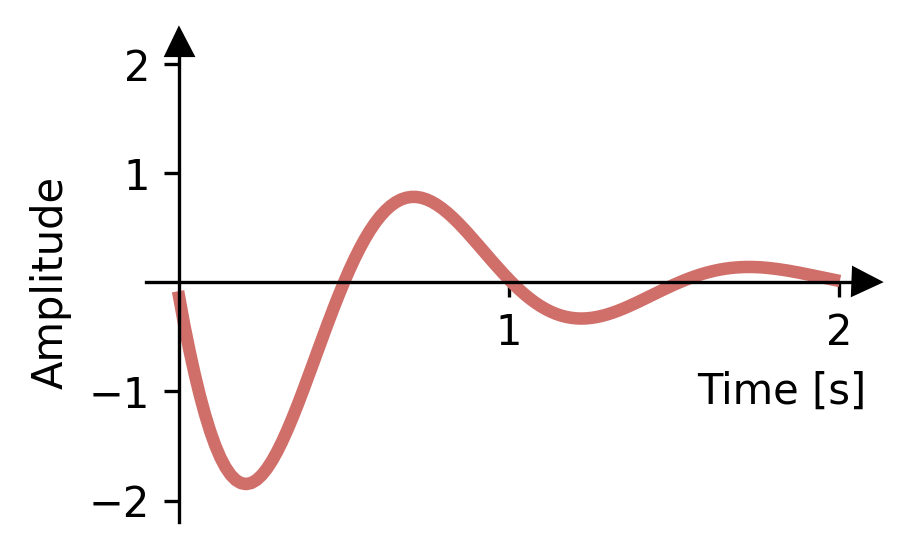

In [13]:
filterBankShort = [waveletFunc(w, w) for w in widths]

fig, ax = plt.subplots(1, 1, figsize=(3,2), sharex=True, sharey=True)
fig.subplots_adjust(bottom=0.1, top=0.9, left=0.15, right=0.95)

ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

b, a = prony(filterBankShort[1], min(2,w-1-(w-1)//2), min(2,(w-1)//2))
b = -b
dlti = signal.dlti(b, a, dt=1/sampleFreq)
t_, y_ = signal.dimpulse(dlti, t=np.arange(2*widths[1])/sampleFreq)
ax.plot(t_, 10*np.squeeze(y_), color=f'#d06f6aff', lw=3)

ax.set_ylabel('Amplitude')
ax.set_xlabel('Time [s]', loc='right')
ax.set_xticks([1,2])
ax.set_yticks([-2,-1,1,2])
ax.set_ylim(-2.2,2.2)
fig.savefig('./../results/iir_filter.pdf', dpi=150)

2.0 1.0000e+00 -1.9701e+00 9.7261e-01 4.9479e-03 4.7474e-03 -1.6064e-04
Max magnitude [dB]: 17.138979289417556
1.0 1.0000e+00 -1.9388e+00 9.4859e-01 1.3830e-02 1.2726e-02 -8.2340e-04
Max magnitude [dB]: 14.301252220651621
0.5 1.0000e+00 -1.8712e+00 9.0818e-01 3.8193e-02 3.2319e-02 -3.7464e-03
Max magnitude [dB]: 11.62780628842116
0.25 1.0000e+00 -1.7111e+00 8.4483e-01 1.0288e-01 7.4190e-02 -1.2713e-02
Max magnitude [dB]: 9.208617734232185
0.125 1.0000e+00 -1.3027e+00 7.4472e-01 2.6283e-01 1.4573e-01 -2.7105e-02
Max magnitude [dB]: 7.018253224746535


Text(0.5, 0, 'Frequency [Hz]')

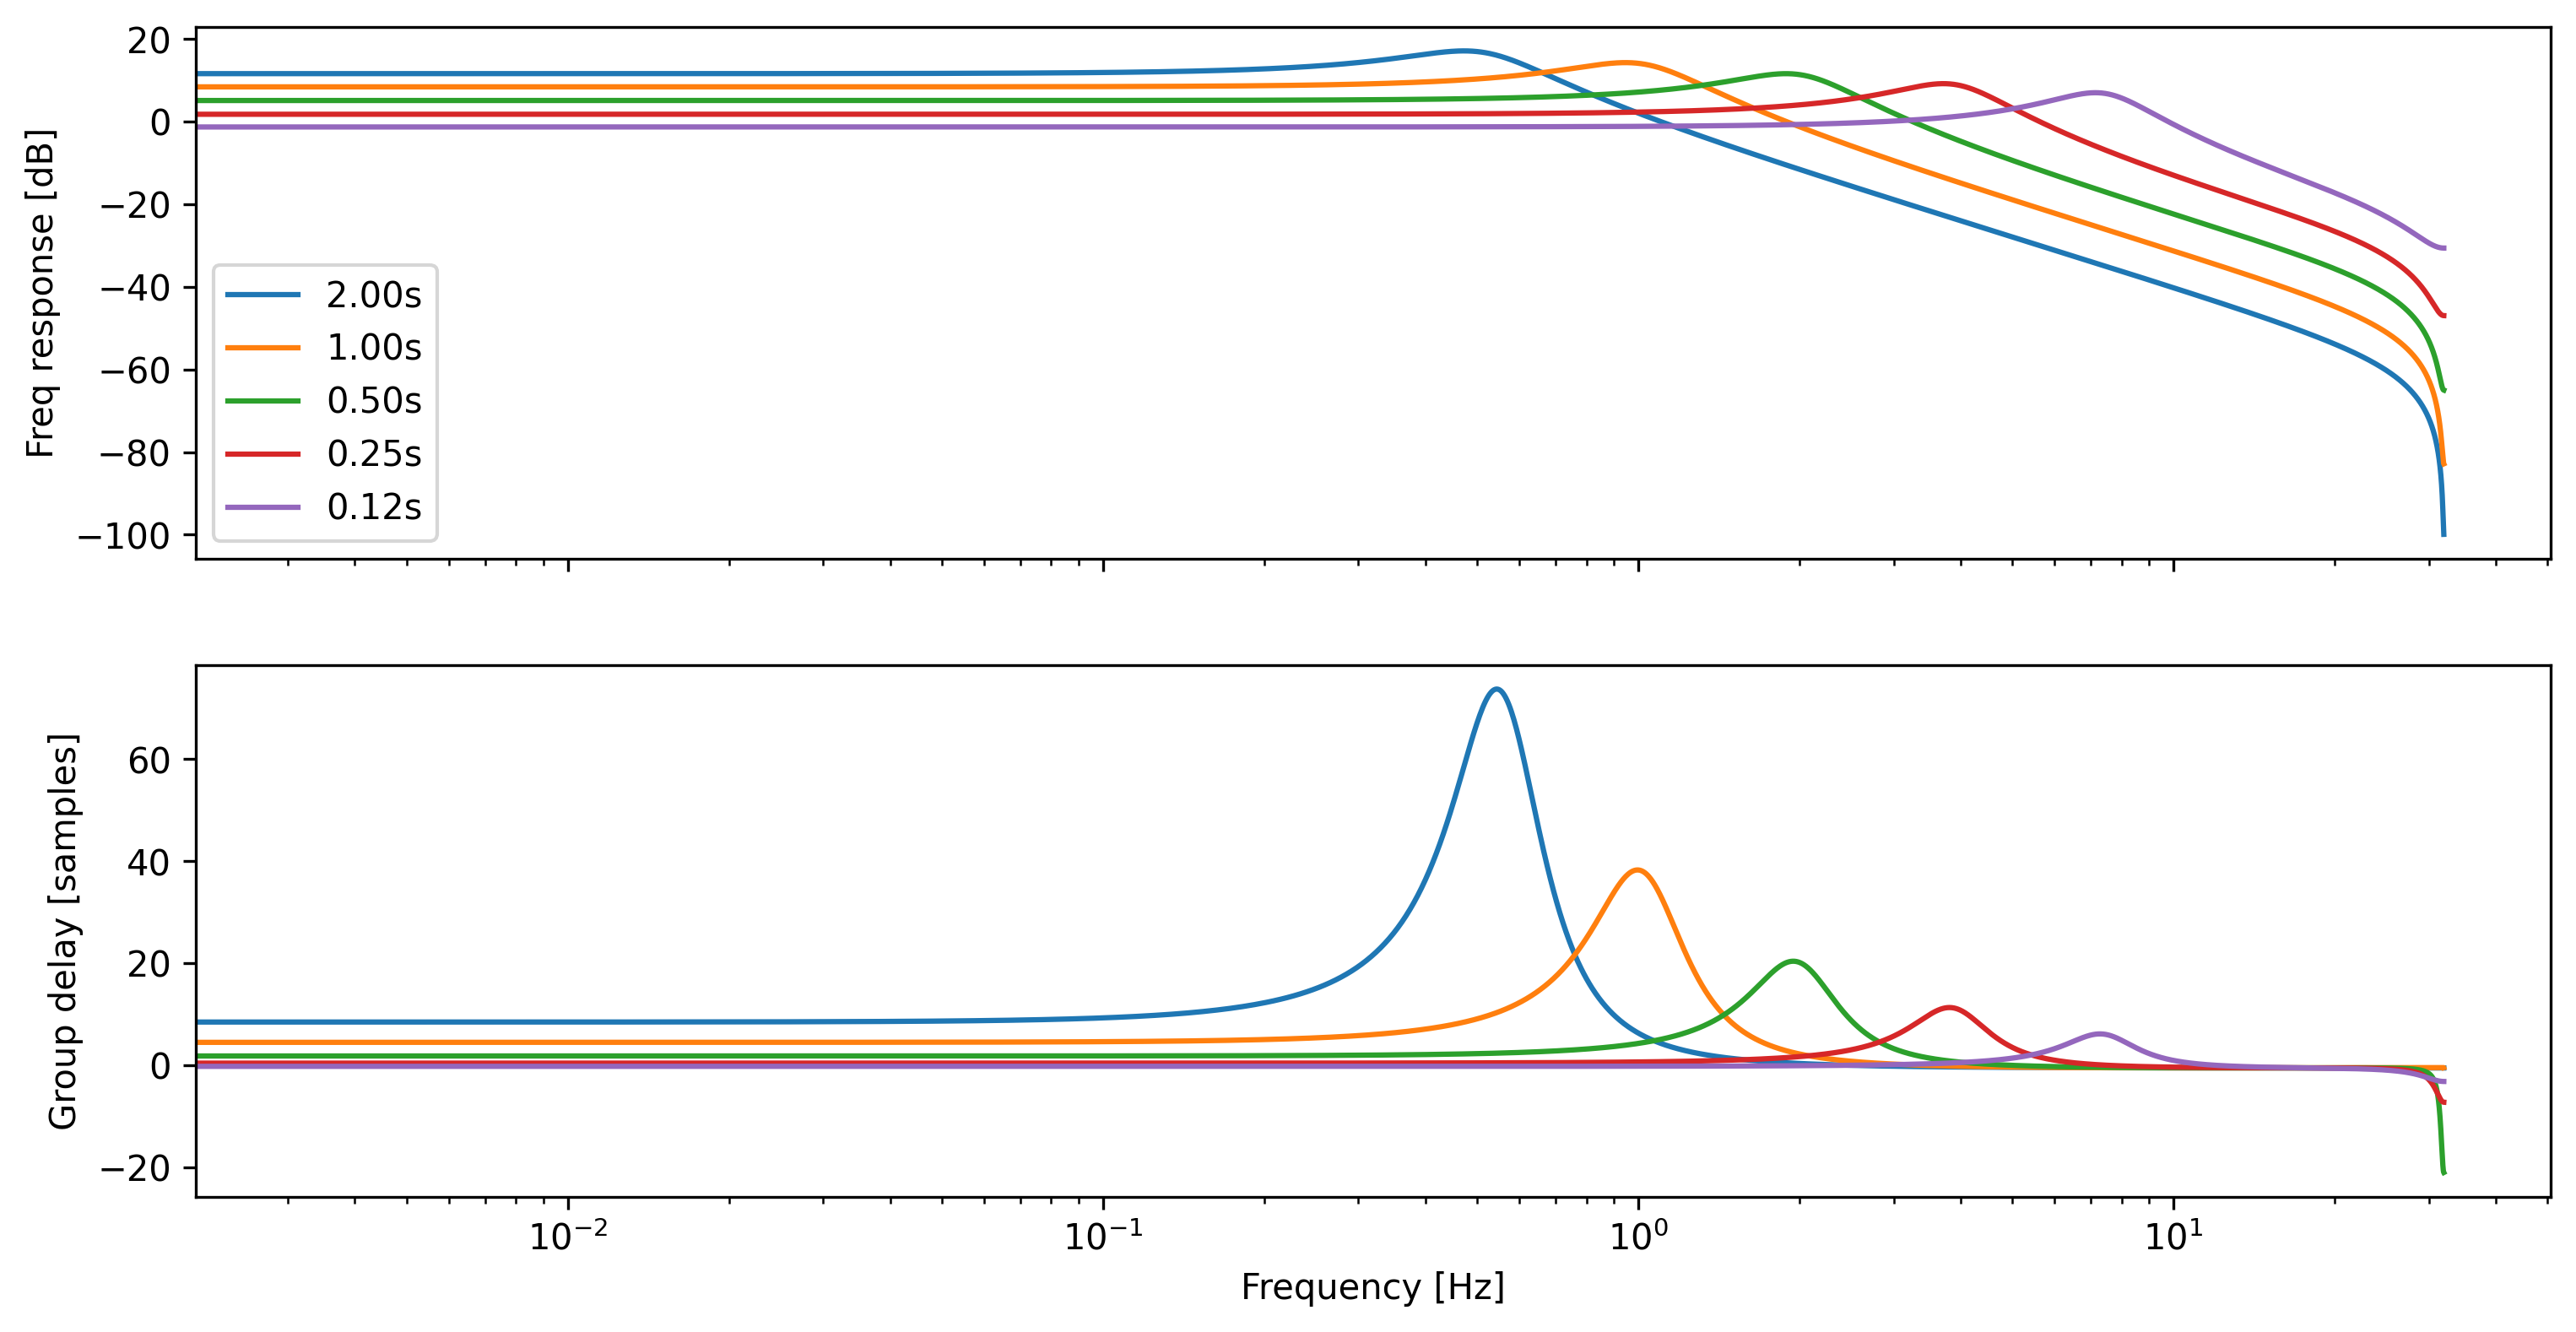

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(12,6), sharex=True)

for fi, (f, w) in enumerate(zip(filterBankShort, widths)):
    b, a = prony(f, min(2,w-1-(w-1)//2), min(2,(w-1)//2))
    # b, a = np.round(2**15 * b).to(int), np.round(2**15 * a * 8).to(int)
    print(w.item()/sampleFreq, ' '.join([f'{i:.4e}' for i in a.numpy()]), ' '.join([f'{i:.4e}' for i in b.numpy()]))
    dlti = signal.dlti(b, a, dt=1/sampleFreq)
    w, mag, phase = signal.dbode(dlti, n=10_000)
    w, gd = signal.group_delay((np.round(b,3), np.round(a,3)), w=w, fs=2*np.pi*sampleFreq)
    print(f'Max magnitude [dB]: {mag.max()}')
    ax[0].semilogx(w/(2*np.pi), mag, label=f'{1/frequencies[fi]:.2f}s')
    # ax[1].semilogx(w/(2*np.pi), phase)
    ax[1].semilogx(w/(2*np.pi), gd)
ax[0].legend()
ax[0].set_ylabel('Freq response [dB]')
ax[1].set_ylabel('Group delay [samples]')
ax[1].set_xlabel('Frequency [Hz]')

In [10]:
10 ** (17.138979289417556 / 20)

7.193644378967399